IMPORTS:

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("HR_Attrition.csv") 
df_visuals = df.copy()

# Task-3: Exploratory Data Analysis (EDA)

Attrition Based on Department:

In [3]:
print("Attrition based on Department:\n")
dept_attrition = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
dept = dept_attrition['Yes'].idxmax()
dept_per = dept_attrition['Yes'].max()
print(f"The department which loses the most employees is {dept} with an attrition rate of {dept_per:.2f}%")

Attrition based on Department:

The department which loses the most employees is Sales with an attrition rate of 20.63%


Attrition Based on Job Role:

In [4]:
print("Attrition based on Job Role:\n")
job_attrition = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack() * 100
job = job_attrition['Yes'].idxmax()
job_per = job_attrition['Yes'].max()
print(f"The Job role that have highest exit rate is {job} with an attrition rate of {job_per:.2f}%")

Attrition based on Job Role:

The Job role that have highest exit rate is Sales Representative with an attrition rate of 39.76%


Attrition based on Income:

In [5]:
income = df.groupby('Attrition')['MonthlyIncome'].median()
left_income = income['Yes']
stayed_income = income['No']
pay_diff = ((stayed_income - left_income) / stayed_income) * 100
print(f"Yes, lower-paid employees leave significantly more.\nEmployees who left had a median monthly income of ${left_income:,.2f} which is {pay_diff:.1f}% lower than those who stayed ${stayed_income:,.2f}")

Yes, lower-paid employees leave significantly more.
Employees who left had a median monthly income of $3,202.00 which is 38.5% lower than those who stayed $5,204.00


Attrition based on Work-Life-Balance:

In [6]:
wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].value_counts(normalize=True).unstack() * 100
worst = wlb_attrition['Yes'].idxmax()
best = wlb_attrition['No'].max()
print(f"Yes, Employees with a Work-Life Balance rating of {worst} (worst) "
      f"lose the most employees, with a staggering attrition rate of {best:.2f}%")

Yes, Employees with a Work-Life Balance rating of 1 (worst) lose the most employees, with a staggering attrition rate of 85.78%


Attrition based on Working Years:

In [7]:
left_df = df[df['Attrition'] == 'Yes']
peak_year = left_df['YearsAtCompany'].mode()[0]
peak_year_exits = len(left_df[left_df['YearsAtCompany']==peak_year])
print(f"Employees leave the most at Year {peak_year} of their tenure.")

Employees leave the most at Year 1 of their tenure.


Top 5 Business Insights:
-
1. Sales Rep Risk: With frontline attrition at 39.8% and compared to senior roles (less than 5%), this is a serious issue for Sales Representatives.

2. Income Cliff: Mid earners lose income dramatically to low earners; median incomes of those who leave are 3,207 v/s 5,204 for those who remain.

3. Non-linear Attrition: There are multiple peaks in attrition – one at the 1-year mark (onboarding friction) and one at the 5-year mark (career stagnation).

4. The Burnout Trigger, which is defined as a Work-Life Balance rating of 1 (Poor), doubles the baseline exit rate (31.3%), and signals potential burnout in a workplace.

5. Overtime Catalyst: Workers who work overtime have an abysmal 30.5% turnover rate, while those who do not have a much more stable 10.4% turnover.

# Task-1: Data Loading & Exploration

In [8]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [9]:
df.shape # No. of rows and cols

(1470, 35)

In [10]:
total_exits = len(left_df)
print("Total Number of Employees left are: ", total_exits)

Total Number of Employees left are:  237


In [11]:
Attrition_rate = df["Attrition"].value_counts(normalize=True) * 100
print(Attrition_rate.map("{:.2f}%".format))

Attrition
No     83.88%
Yes    16.12%
Name: proportion, dtype: str


In [12]:
print("Following are the cols which have Categorical Values\n",df.select_dtypes(include=['object', 'category']).columns.tolist())

Following are the cols which have Categorical Values
 ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


As per my observation, the Attrition rate is imbalanced i.e. 16.12% -> Yes and 83.88% -> No.
-

# Task-2: Data Cleaning & Preprocessing

In [13]:
print(df.isnull().sum()) # Checking for missing values...

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [14]:
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns = cols_to_drop)
print(f"Remaining cols: {df.shape[1]}")

Remaining cols: 31


In [15]:
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

In [16]:
cols_to_encode = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_result = encoder.fit_transform(df[cols_to_encode])
encoded_df = pd.DataFrame(
    encoded_result,
    columns = encoder.get_feature_names_out(cols_to_encode)
).astype(int)
df = df.drop(columns = cols_to_encode).join(encoded_df)
print(df.head(1))

   Age  Attrition  DailyRate  DistanceFromHome  Education  \
0   41          1       1102                 1          2   

   EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
0                        2          94               3         2   

   JobSatisfaction  ...  JobRole_Laboratory Technician  JobRole_Manager  \
0                4  ...                              0                0   

   JobRole_Manufacturing Director  JobRole_Research Director  \
0                               0                          0   

   JobRole_Research Scientist  JobRole_Sales Executive  \
0                           0                        1   

   JobRole_Sales Representative  MaritalStatus_Married  MaritalStatus_Single  \
0                             0                      0                     1   

   OverTime_Yes  
0             1  

[1 rows x 45 columns]


In [17]:
print(df.isnull().sum())

Age                                  0
Attrition                            0
DailyRate                            0
DistanceFromHome                     0
Education                            0
EnvironmentSatisfaction              0
HourlyRate                           0
JobInvolvement                       0
JobLevel                             0
JobSatisfaction                      0
MonthlyIncome                        0
MonthlyRate                          0
NumCompaniesWorked                   0
PercentSalaryHike                    0
PerformanceRating                    0
RelationshipSatisfaction             0
StockOptionLevel                     0
TotalWorkingYears                    0
TrainingTimesLastYear                0
WorkLifeBalance                      0
YearsAtCompany                       0
YearsInCurrentRole                   0
YearsSinceLastPromotion              0
YearsWithCurrManager                 0
BusinessTravel_Travel_Frequently     0
BusinessTravel_Travel_Rar

In [18]:
X = df.drop(columns = ['Attrition'])
y = df['Attrition']

In [19]:
continuous_cols = [col for col in X.columns if X[col].nunique() > 5] #Standardizing only those cols which are continuous in nature...
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[continuous_cols] = scaler.fit_transform(X_scaled[continuous_cols])
X_scaled.head(1)

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.44635,0.742527,-1.010909,2,2,1.383138,3,2,4,-0.10835,...,0,0,0,0,0,1,0,0,1,1


# Task-4: Model Building & Comparison

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2)

In [21]:
lr = LogisticRegression(class_weight = 'balanced', random_state = 19)
rf = RandomForestClassifier(class_weight = 'balanced', random_state = 19)
gnb = GradientBoostingClassifier(random_state=19)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gnb.fit(X_train, y_train, sample_weight = sample_weights)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

# Task-5: Model Evaluation

In [22]:
models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'Gradient Boosting': gnb
}
results_list = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    results_list.append({
        'Model': name,
        'Accuracy': f"{accuracy * 100:.2f}%",
        'Precision': f"{precision * 100:.2f}%",
        'Recall': f"{recall * 100:.2f}%",
        'F1-Score': f"{f1 * 100:.2f}%",
        'ROC AUC Score': f"{roc_auc * 100:.1f}%"
    })
results_df = pd.DataFrame(results_list)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
results_df

Confusion Matrix:
 [[216  27]
 [ 22  29]]


,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC Score
0,Logistic Regression,76.19%,39.78%,72.55%,51.39%,80.6%
1,Random Forest,84.01%,100.00%,7.84%,14.55%,81.3%
2,Gradient Boosting,83.33%,51.79%,56.86%,54.21%,79.1%


Since, Random Forest is the best Model below given is its feature importance:

In [23]:
importances = rf.feature_importances_
feature_names = X_train.columns
rf_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)
importance_df = pd.DataFrame({
    'Rank': range(1, len(X_train.columns) + 1),
    'Feature Name': rf_importances.index,
    'Importance Weight': rf_importances.values,
    'Impact Percentage': [f"{val * 100:.2f}%" for val in rf_importances.values]
})
importance_df.head(15) 

,Rank,Feature Name,Importance Weight,Impact Percentage
0,1,MonthlyIncome,0.073591,7.36%
1,2,OverTime_Yes,0.059631,5.96%
2,3,Age,0.054908,5.49%
3,4,DailyRate,0.051165,5.12%
4,5,DistanceFromHome,0.047361,4.74%
5,6,MonthlyRate,0.046450,4.64%
6,7,TotalWorkingYears,0.046155,4.62%
7,8,HourlyRate,0.044478,4.45%
8,9,StockOptionLevel,0.040049,4.00%
9,10,YearsAtCompany,0.038988,3.90%


# Task-6: Visualization

Chart 1: Bar chart showing attrition rate by Department and Job Role


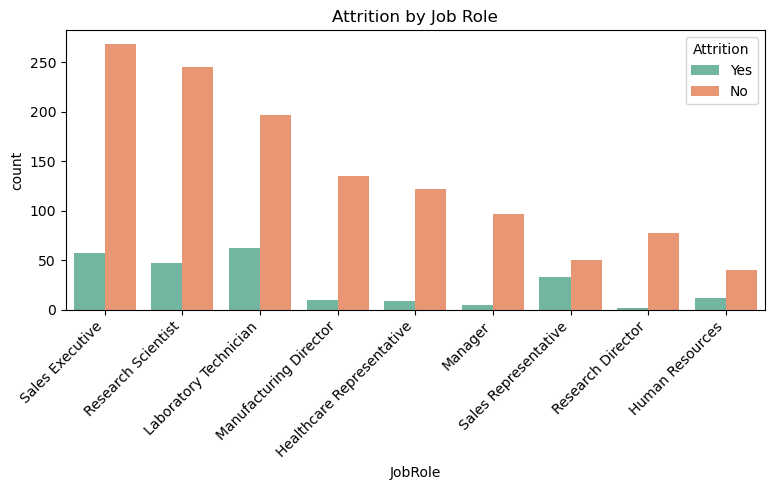

In [24]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.countplot(data=df_visuals, x='JobRole', hue="Attrition", palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title("Attrition by Job Role")
plt.tight_layout()
plt.show()

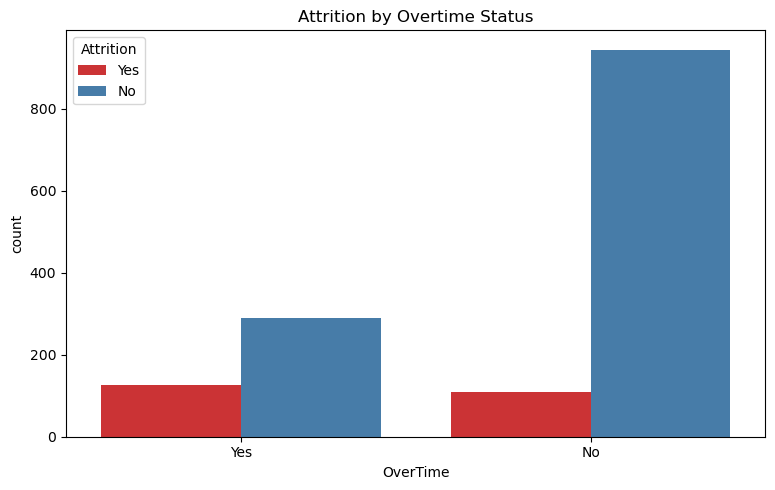

In [25]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,2)
sns.countplot(data=df_visuals, x='OverTime', hue='Attrition', palette='Set1')
plt.title('Attrition by Overtime Status')
plt.tight_layout()
plt.show()

Chart 2: Box plot comparing Monthly Income of employees who left vs stayed

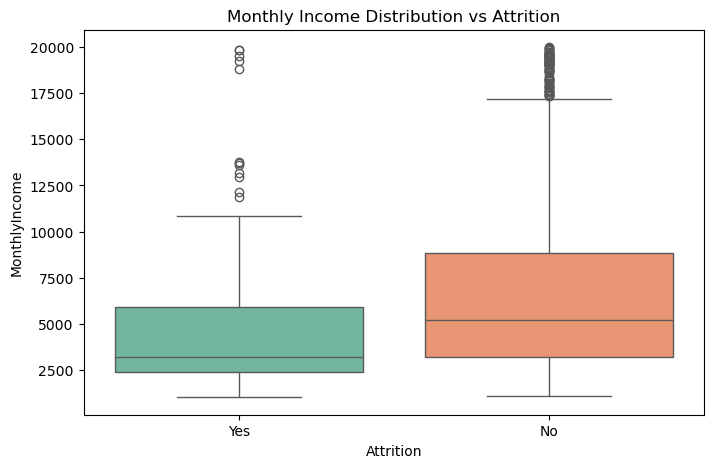

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_visuals, x='Attrition', y='MonthlyIncome', palette='Set2')
plt.title('Monthly Income Distribution vs Attrition')
plt.show()

Chart 3: Confusion Matrix heatmap for your best model


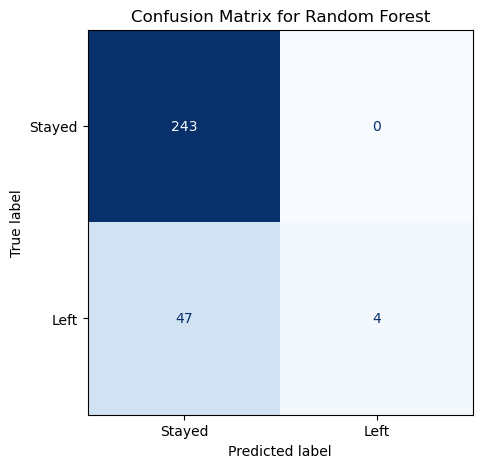

In [27]:
cm = confusion_matrix(y_test, rf.predict(X_test))
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left']).plot(cmap='Blues', ax=plt.gca(), colorbar=False)
plt.title('Confusion Matrix for Random Forest')
plt.show()

Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model


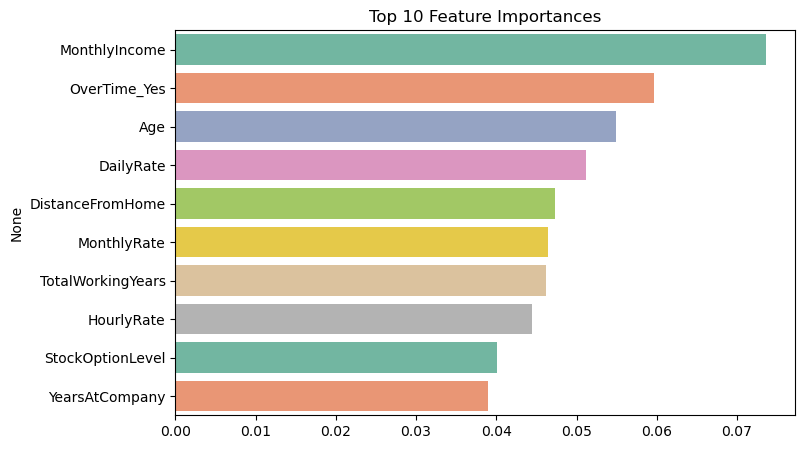

In [28]:
rf_importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_10 = rf_importances.head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_10.values, y=top_10.index, palette='Set2')
plt.title('Top 10 Feature Importances')
plt.show()

Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph

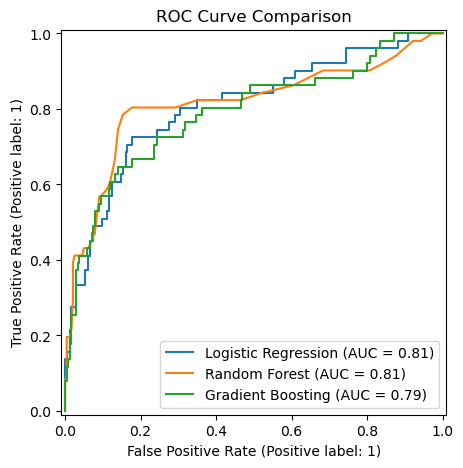

In [29]:
plt.figure(figsize=(8, 5))
ax = plt.gca()
RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax, name='Random Forest')
RocCurveDisplay.from_estimator(gnb, X_test, y_test, ax=ax, name='Gradient Boosting')
plt.title('ROC Curve Comparison')
plt.show()